In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('student_clustering.csv')
print("The shape of data is",df.shape)
df.head()

The shape of data is (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [10]:
X = df.to_numpy()

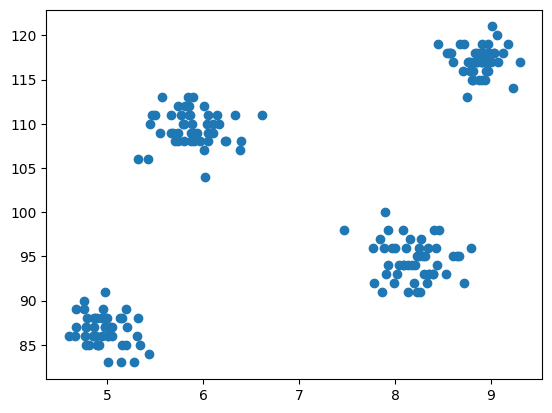

In [11]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'])

# finding optimal k using wcss(elbow method)

In [6]:
from sklearn.cluster import KMeans

In [30]:
inertias = []
k_range = range(2, 11)  # practically keep upperlimit less 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

In [31]:
inertias

[4184.141270000001,
 2364.005583420084,
 681.9696600000003,
 514.1616803171116,
 437.48049222807026,
 312.1712145985568,
 242.41587382556423,
 219.5382138115586,
 184.00599197173173]

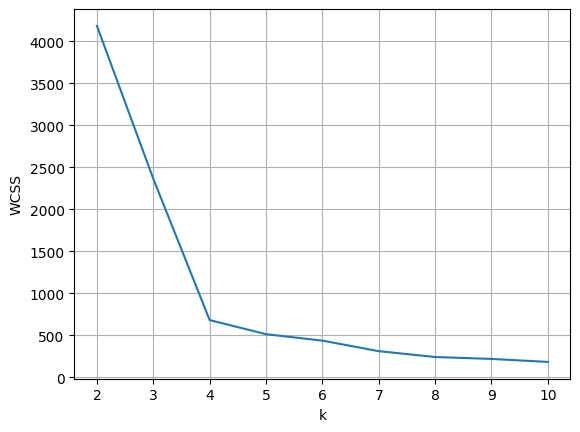

In [37]:
plt.plot(k_range,inertias)
plt.ylabel("WCSS")
plt.xlabel("k")
plt.grid()
plt.show()

4 is optimal value

# Finding optimal k using silhouette_score

In [33]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

In [34]:
np.argmax(sil_scores)

np.int64(0)

In [35]:
sil_scores

[0.7544965767963053,
 0.7112751364478009,
 0.7349682510969364,
 0.6922288315496768,
 0.6410948236088447,
 0.5949151395259331,
 0.5626302988232927,
 0.565145444253958,
 0.5665087296162703]

In [36]:
# silhouette score is failling in this case --- as data has clear boundries

# Implementation of kmeans clustering

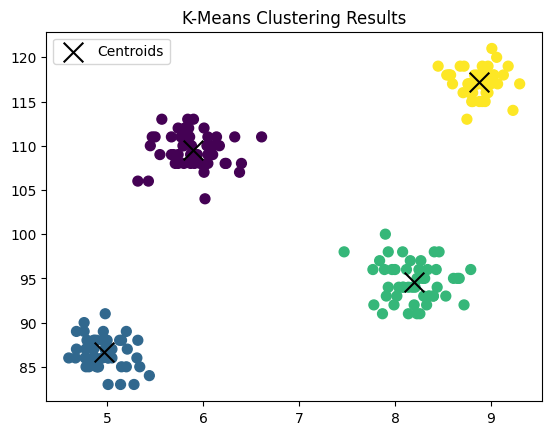

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4, 
    init='k-means++',
    n_init=10, 
    max_iter=300, 
    random_state=42)

kmeans.fit(X)  # we can use fit_predict together

y_kmeans = kmeans.predict(X)      # The cluster label for each point
centers = kmeans.cluster_centers_ # The coordinates of the 4 centroids

# Plot the data points, colored by their cluster label
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot the centroids as large black 'X's
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='x', label='Centroids')

plt.title('K-Means Clustering Results')
plt.legend()
plt.show()